In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import joblib
from scipy.stats import zscore
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

# Grafik-Stil
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Parameter
WINDOW_LEN = 170
INPUT_TRAIN = 'training_data_nan_bereinigt.csv'
INPUT_TEST = 'test_data_nan_bereinigt.csv'
MODEL_FILE = 'sonar_model_optimized.pkl'


def natural_sort_key(s):
    """
    Sorgt für korrekte Sortierung: S_2 kommt VOR S_10.
    Wichtig, damit das Signal nicht zeitlich durcheinander gerät.
    """
    return [int(text) if text.isdigit() else text.lower()
            for text in re.split('(\d+)', s)]


def process_signal_fast(sig, win_len, p_mask, v_start):
    """
    Exakte Nachbildung der Matlab-Logik (0-basierte Indizes angepasst).
    """
    sig_len = len(sig)

    # 1. Global Peak Search (maskiert)
    roi_start = min(sig_len, p_mask)
    if roi_start >= sig_len:
        peak_idx = 0
    else:
        peak_rel = np.argmax(sig[roi_start:])
        peak_idx = roi_start + peak_rel

    peak_val_raw = sig[peak_idx] if peak_idx < sig_len else 0

    # 2. Valley Search
    v_s = min(sig_len, v_start)
    v_e = peak_idx

    if v_s >= v_e:
        valley_idx = v_s
    else:
        v_rel = np.argmin(sig[v_s:v_e])
        valley_idx = v_s + v_rel

    valley_val = sig[valley_idx] if valley_idx < sig_len else 0

    # 3. Onset Detection
    threshold = valley_val + (peak_val_raw - valley_val) * 0.10
    rise_segment = sig[valley_idx:peak_idx] if valley_idx < peak_idx else np.array([
    ])

    if len(rise_segment) == 0:
        onset_abs = valley_idx
    else:
        below_idx = np.where(rise_segment < threshold)[0]
        if len(below_idx) == 0:
            onset_abs = valley_idx
        else:
            onset_abs = valley_idx + below_idx[-1]

    # 4. Fenster ausschneiden
    start_idx = onset_abs
    end_idx = start_idx + win_len
    aligned_window = np.zeros(win_len)

    read_start = max(0, start_idx)
    read_end = min(sig_len, end_idx)
    write_start = read_start - start_idx
    write_end = write_start + (read_end - read_start)

    if read_start < read_end and write_start < win_len:
        aligned_window[write_start:write_end] = sig[read_start:read_end]

    # 5. Features berechnen
    raw_energy = np.sum(aligned_window**2)
    s_val = np.std(aligned_window)
    m_val = np.mean(aligned_window)

    if s_val > 1e-9:
        aligned_window_norm = (aligned_window - m_val) / s_val
    else:
        aligned_window_norm = aligned_window - m_val

    loc = peak_idx - start_idx
    loc = max(0, min(win_len - 1, loc))

    peak_norm = aligned_window_norm[loc]

    # Breite (FWHM)
    half = peak_norm * 0.5
    left_part = aligned_window_norm[:loc]
    left_idxs = np.where(left_part < half)[0]
    left_idx = left_idxs[-1] if len(left_idxs) > 0 else 0

    right_part = aligned_window_norm[loc:]
    right_idxs = np.where(right_part < half)[0]
    width_idx = (loc + right_idxs[0]) if len(right_idxs) > 0 else (win_len - 1)

    width = width_idx - left_idx

    return [raw_energy, peak_val_raw, peak_norm, width], aligned_window_norm

In [55]:
def load_and_extract(filename, win_len):
    # 1. Laden & NaN Behandlung
    try:
        df = pd.read_csv(filename, sep=';')
    except:
        df = pd.read_csv(filename, sep=',')  # Fallback

    df.columns = df.columns.str.strip()

    # NaN Fix: Matlab ignoriert NaNs oft, Python braucht Nullen oder Removal
    if df.isna().sum().sum() > 0:
        print(
            f"Hinweis: {df.isna().sum().sum()} NaNs in {filename} gefunden. Fülle mit 0.")
        df.fillna(0, inplace=True)

    # 2. Merge High/Low
    df_high = df[df['Frequency'].str.lower(
    ) == 'high'].copy().sort_values('Timestamp')
    df_low = df[df['Frequency'].str.lower(
    ) == 'low'].copy().sort_values('Timestamp')

    n = min(len(df_high), len(df_low))
    df_high = df_high.iloc[:n]
    df_low = df_low.iloc[:n]

    # 3. Spalten identifizieren & SORTIEREN (Kritisch!)
    hf_cols = sorted(
        [c for c in df_high.columns if c.startswith('S_')], key=natural_sort_key)
    lf_cols = sorted(
        [c for c in df_low.columns if c.startswith('S_')], key=natural_sort_key)

    # Daten extrahieren
    data_hf = df_high[hf_cols].values
    data_lf = df_low[lf_cols].values
    labels = df_high['class_name'].values

    # 4. Feature Loop
    num_samples = len(labels)
    num_features = 8 + 2 * win_len
    X = np.zeros((num_samples, num_features))

    print(f"Extrahiere Features aus {filename} ({num_samples} Samples)...")
    for i in range(num_samples):
        stats_hf, win_hf = process_signal_fast(data_hf[i], win_len, 30, 20)
        stats_lf, win_lf = process_signal_fast(data_lf[i], win_len, 78, 55)
        X[i, :] = np.concatenate([stats_hf, stats_lf, win_hf, win_lf])

    return X, labels


# Ausführen
if os.path.isfile(INPUT_TRAIN) and os.path.isfile(INPUT_TEST):
    X_train_raw, Y_train = load_and_extract(INPUT_TRAIN, WINDOW_LEN)
    X_test_raw, Y_test = load_and_extract(INPUT_TEST, WINDOW_LEN)
    print("Daten erfolgreich geladen.")
else:
    print("FEHLER: Dateien nicht gefunden.")

Hinweis: 468 NaNs in training_data_nan_bereinigt.csv gefunden. Fülle mit 0.
Extrahiere Features aus training_data_nan_bereinigt.csv (54 Samples)...
Hinweis: 3 NaNs in test_data_nan_bereinigt.csv gefunden. Fülle mit 0.
Extrahiere Features aus test_data_nan_bereinigt.csv (18 Samples)...
Daten erfolgreich geladen.


In [ ]:
# Feature Split: 8 Stats vs. Waveform
NUM_STATS = 8
X_stats_train = X_train_raw[:, :NUM_STATS]
X_stats_test = X_test_raw[:, :NUM_STATS]
X_wave_train = X_train_raw[:, NUM_STATS:]
X_wave_test = X_test_raw[:, NUM_STATS:]

# 1. PCA Pipeline
print("Berechne PCA (Ziel: 95% Varianz)...")
scaler = StandardScaler()
X_wave_train_std = scaler.fit_transform(X_wave_train)
X_wave_test_std = scaler.transform(X_wave_test)

# PCA
pca = PCA(n_components=0.24, random_state=42)
X_pca_train = pca.fit_transform(X_wave_train_std)
X_pca_test = pca.transform(X_wave_test_std)

print(f"   -> {pca.n_components_} Komponenten genutzt.")

# Kombinieren
X_train_final = np.hstack([X_stats_train, X_pca_train])
X_test_final = np.hstack([X_stats_test, X_pca_test])

# 2. Training (Optimierter Random Forest)
# Mehr Bäume (300) für mehr Stabilität
print("Trainiere Random Forest (300 Trees)...")
model = RandomForestClassifier(n_estimators=300,
                               random_state=42,
                               max_features='sqrt',  # wie Matlab
                               min_samples_leaf=1)  # wie Matlab
model.fit(X_train_final, Y_train)

# 3. Evaluation
Y_pred = model.predict(X_test_final)
acc = accuracy_score(Y_test, Y_pred)

print("================================================")
print(f"GENAUIGKEIT: {acc * 100:.1f}%")
print("================================================")

# Speichern
joblib.dump({'model': model, 'pca': pca, 'scaler': scaler}, MODEL_FILE)

Berechne PCA (Ziel: 95% Varianz)...
   -> 28 Komponenten genutzt.
Trainiere Random Forest (300 Trees)...
GENAUIGKEIT: 61.1%


['sonar_model_optimized.pkl']

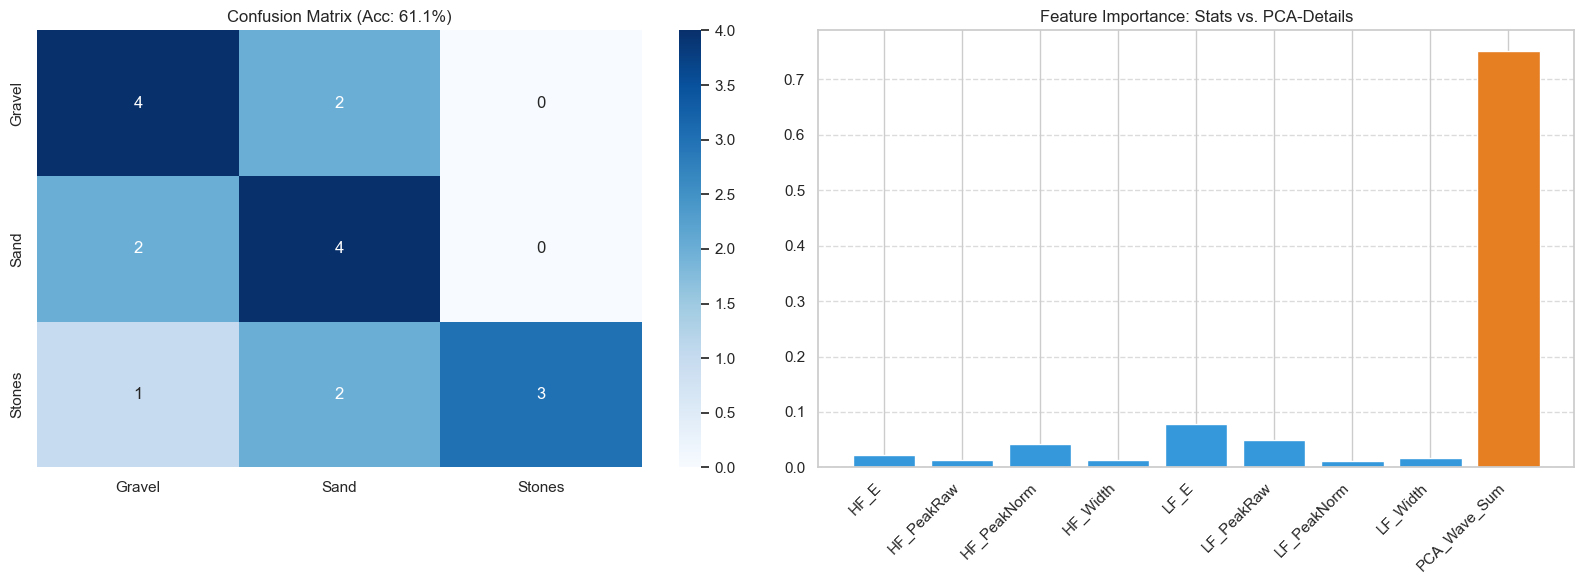

In [57]:
# Visualisierung wie angefordert
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=np.unique(Y_train), yticklabels=np.unique(Y_train))
axes[0].set_title(f"Confusion Matrix (Acc: {acc*100:.1f}%)")

# Feature Importance
imps = model.feature_importances_
imp_stats = imps[:8]
imp_pca_sum = np.sum(imps[8:])

labels = ['HF_E', 'HF_PeakRaw', 'HF_PeakNorm', 'HF_Width',
          'LF_E', 'LF_PeakRaw', 'LF_PeakNorm', 'LF_Width',
          'PCA_Wave_Sum']
values = np.append(imp_stats, imp_pca_sum)
colors = ['#3498db']*8 + ['#e67e22']  # Blau für Stats, Orange für PCA

axes[1].bar(labels, values, color=colors)
axes[1].set_title("Feature Importance: Stats vs. PCA-Details")
plt.xticks(rotation=45, ha='right')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()